# Diffusion Model per Emerging Jets

Questo notebook implementa un **Denoising Diffusion Model** sulle feature aggregate jet+track.

A differenza di AE/VAE/Flow:

- non ricostruisce direttamente l'input pulito come un autoencoder;
- non calcola una likelihood esatta come un normalizing flow;
- impara invece a predire il rumore aggiunto a un esempio background.

Training:

```text
x0 = jet background aggregato
epsilon = rumore gaussiano
t = timestep casuale
xt = sqrt(alpha_bar_t) * x0 + sqrt(1-alpha_bar_t) * epsilon
modello(xt, t) -> epsilon_pred
loss = MSE(epsilon_pred, epsilon)
```

Anomaly score:

```text
score = errore medio di denoising su più timestep
```

Se un jet signal non è background-like, il modello dovrebbe predire peggio il rumore e quindi avere score più alto.

## 1. Import e GPU

In [1]:
from pathlib import Path
import json
import math
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

np.random.seed(42)
torch.manual_seed(42)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch: 2.12.0+cu126
CUDA available: True
CUDA version: 12.6
GPU count: 1
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Using device: cuda


## 2. Path dei dataset preprocessati

In [2]:
# Questo notebook NON ricrea gli .npz.
# Usa i dataset già preprocessati dai notebook precedenti.

CANDIDATE_DATASETS = [
    {
        "name": "processed_flow",
        "dir": Path("processed_flow"),
        "files": {
            "val": "processed_flow_jet_track_val.npz",
            "test_background": "processed_flow_jet_track_test_background.npz",
            "test_signal": "processed_flow_jet_track_test_signal.npz",
        },
    },
    {
        "name": "processed_clean",
        "dir": Path("processed_clean"),
        "files": {
            "val": "processed_clean_jet_track_val.npz",
            "test_background": "processed_clean_jet_track_test_background.npz",
            "test_signal": "processed_clean_jet_track_test_signal.npz",
        },
    },
    {
        "name": "processed",
        "dir": Path("processed"),
        "files": {
            "val": "processed_jet_track_val.npz",
            "test_background": "processed_jet_track_test_background.npz",
            "test_signal": "processed_jet_track_test_signal.npz",
        },
    },
]

selected = None

for candidate in CANDIDATE_DATASETS:
    base = candidate["dir"]
    files = {k: base / v for k, v in candidate["files"].items()}
    ok = all(path.exists() for path in files.values())

    print(candidate["name"], "available:", ok)
    for k, path in files.items():
        print(" ", k, "->", path, "exists:", path.exists())

    if ok and selected is None:
        selected = (candidate["name"], files)

if selected is None:
    raise FileNotFoundError(
        "Non ho trovato dataset preprocessati. "
        "Esegui prima un notebook che crei processed_flow/processed_clean/processed."
    )

DATASET_NAME, processed_files = selected

OUTPUT_DIR = Path("outputs_diffusion")
OUTPUT_DIR.mkdir(exist_ok=True)

print("\nUsing dataset:", DATASET_NAME)
print(processed_files)

processed_flow available: True
  val -> processed_flow\processed_flow_jet_track_val.npz exists: True
  test_background -> processed_flow\processed_flow_jet_track_test_background.npz exists: True
  test_signal -> processed_flow\processed_flow_jet_track_test_signal.npz exists: True
processed_clean available: True
  val -> processed_clean\processed_clean_jet_track_val.npz exists: True
  test_background -> processed_clean\processed_clean_jet_track_test_background.npz exists: True
  test_signal -> processed_clean\processed_clean_jet_track_test_signal.npz exists: True
processed available: True
  val -> processed\processed_jet_track_val.npz exists: True
  test_background -> processed\processed_jet_track_test_background.npz exists: True
  test_signal -> processed\processed_jet_track_test_signal.npz exists: True

Using dataset: processed_flow
{'val': WindowsPath('processed_flow/processed_flow_jet_track_val.npz'), 'test_background': WindowsPath('processed_flow/processed_flow_jet_track_test_backg

## 3. Carica dataset

In [3]:
data_train = np.load(processed_files["val"], allow_pickle=True)
data_bg = np.load(processed_files["test_background"], allow_pickle=True)
data_sig = np.load(processed_files["test_signal"], allow_pickle=True)

X_jets_train = data_train["X_jets"].astype(np.float32)
X_tracks_train = data_train["X_tracks"].astype(np.float32)
mask_train = data_train["track_mask"].astype(bool)

X_jets_bg = data_bg["X_jets"].astype(np.float32)
X_tracks_bg = data_bg["X_tracks"].astype(np.float32)
mask_bg = data_bg["track_mask"].astype(bool)

X_jets_sig = data_sig["X_jets"].astype(np.float32)
X_tracks_sig = data_sig["X_tracks"].astype(np.float32)
mask_sig = data_sig["track_mask"].astype(bool)

jet_feature_names = list(data_train["jet_feature_names"])
track_feature_names = list(data_train["track_feature_names"])

print("train:", X_jets_train.shape, X_tracks_train.shape, mask_train.shape)
print("background:", X_jets_bg.shape, X_tracks_bg.shape, mask_bg.shape)
print("signal:", X_jets_sig.shape, X_tracks_sig.shape, mask_sig.shape)

print("\nJet features:")
print(jet_feature_names)

print("\nTrack features:")
print(track_feature_names)

if "y" in data_train:
    print("\ntrain y:", np.unique(data_train["y"], return_counts=True))
if "meta_isDisplaced" in data_train:
    print("train meta_isDisplaced:", np.unique(data_train["meta_isDisplaced"], return_counts=True))

if "y" in data_sig:
    print("\nsignal y:", np.unique(data_sig["y"], return_counts=True))
if "meta_isDisplaced" in data_sig:
    print("signal meta_isDisplaced:", np.unique(data_sig["meta_isDisplaced"], return_counts=True))

train: (100000, 14) (100000, 200, 12) (100000, 200)
background: (100000, 14) (100000, 200, 12) (100000, 200)
signal: (61966, 14) (61966, 200, 12) (61966, 200)

Jet features:
['pt', 'eta', 'mass', 'energy', 'Qw_clusterSoftDrop', 'C2_clusterSoftDrop', 'D2_clusterSoftDrop', 'Tau1_clusterSoftDrop', 'Tau2_clusterSoftDrop', 'Tau3_clusterSoftDrop', 'Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop', 'ECF1_clusterSoftDrop', 'ECF2_clusterSoftDrop']

Track features:
['d0', 'z0SinTheta', 'dphi', 'deta', 'pt_log1p', 'radiusOfFirstHit', 'numberOfPixelHits', 'numberOfSCTHits', 'numberOfSCTHoles', 'numberOfInnermostPixelLayerHits', 'numberOfPixelSharedHits', 'numberOfSCTSharedHits']

train y: (array([0]), array([100000]))
train meta_isDisplaced: (array([0], dtype=int32), array([100000]))

signal y: (array([1]), array([61966]))
signal meta_isDisplaced: (array([0, 1], dtype=int32), array([ 2322, 59644]))


## 4. Filtri: train background-only, signal displaced, almeno una traccia

In [4]:
# 1. Training solo background-like
if "y" in data_train:
    train_filter = data_train["y"] == 0
    print("Using y == 0 for training filter.")
elif "meta_isDisplaced" in data_train:
    train_filter = data_train["meta_isDisplaced"] == 0
    print("Using meta_isDisplaced == 0 for training filter.")
else:
    train_filter = np.ones(X_jets_train.shape[0], dtype=bool)
    print("No train labels found: using all training jets.")

# 2. Signal: solo veri displaced se disponibile
EVAL_ONLY_TRUE_DISPLACED_SIGNAL = True

if EVAL_ONLY_TRUE_DISPLACED_SIGNAL and "meta_isDisplaced" in data_sig:
    sig_filter = data_sig["meta_isDisplaced"] == 1
    print("Using only true displaced signal jets.")
else:
    sig_filter = np.ones(X_jets_sig.shape[0], dtype=bool)
    print("Using all signal jets.")

# 3. Rimuovi jet senza tracce valide
train_nonempty = mask_train.sum(axis=1) > 0
bg_nonempty = mask_bg.sum(axis=1) > 0
sig_nonempty = mask_sig.sum(axis=1) > 0

print("\nZero-track jets:")
print("train:", np.sum(~train_nonempty), "/", len(train_nonempty))
print("background:", np.sum(~bg_nonempty), "/", len(bg_nonempty))
print("signal:", np.sum(~sig_nonempty), "/", len(sig_nonempty))

train_filter = train_filter & train_nonempty
bg_filter = bg_nonempty
sig_filter = sig_filter & sig_nonempty

print("\nSelected:")
print("train:", train_filter.sum(), "/", len(train_filter))
print("background:", bg_filter.sum(), "/", len(bg_filter))
print("signal:", sig_filter.sum(), "/", len(sig_filter))

X_jets_train = X_jets_train[train_filter]
X_tracks_train = X_tracks_train[train_filter]
mask_train = mask_train[train_filter]

X_jets_bg = X_jets_bg[bg_filter]
X_tracks_bg = X_tracks_bg[bg_filter]
mask_bg = mask_bg[bg_filter]

X_jets_sig = X_jets_sig[sig_filter]
X_tracks_sig = X_tracks_sig[sig_filter]
mask_sig = mask_sig[sig_filter]

print("\nAfter filters:")
print("train:", X_jets_train.shape, X_tracks_train.shape)
print("background:", X_jets_bg.shape, X_tracks_bg.shape)
print("signal:", X_jets_sig.shape, X_tracks_sig.shape)

Using y == 0 for training filter.
Using only true displaced signal jets.

Zero-track jets:
train: 0 / 100000
background: 0 / 100000
signal: 1 / 61966

Selected:
train: 100000 / 100000
background: 100000 / 100000
signal: 59643 / 61966

After filters:
train: (100000, 14) (100000, 200, 12)
background: (100000, 14) (100000, 200, 12)
signal: (59643, 14) (59643, 200, 12)


## 5. Costruisci feature aggregate

In [5]:
def aggregate_track_features(X_tracks, mask):
    features = []

    n_valid = mask.sum(axis=1, keepdims=True).astype(np.float32)
    features.append(n_valid)

    for i in range(X_tracks.shape[-1]):
        vals = X_tracks[:, :, i]
        valid_vals = np.where(mask, vals, np.nan)

        mean = np.nanmean(valid_vals, axis=1, keepdims=True)
        std = np.nanstd(valid_vals, axis=1, keepdims=True)
        median = np.nanmedian(valid_vals, axis=1, keepdims=True)
        q90 = np.nanpercentile(valid_vals, 90, axis=1, keepdims=True)
        maxv = np.nanmax(valid_vals, axis=1, keepdims=True)

        features.extend([mean, std, median, q90, maxv])

    out = np.concatenate(features, axis=1)
    out = np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)
    return out.astype(np.float32)


def build_aggregate_matrix(X_jets, X_tracks, mask, use_jets=True, use_tracks=True):
    parts = []

    if use_jets:
        parts.append(X_jets.astype(np.float32))

    if use_tracks:
        parts.append(aggregate_track_features(X_tracks, mask))

    return np.concatenate(parts, axis=1).astype(np.float32)


def build_aggregate_feature_names(jet_feature_names, track_feature_names, use_jets=True, use_tracks=True):
    names = []

    if use_jets:
        names.extend(jet_feature_names)

    if use_tracks:
        names.append("n_valid_tracks")
        for feat in track_feature_names:
            names.extend([
                f"{feat}_mean",
                f"{feat}_std",
                f"{feat}_median",
                f"{feat}_q90",
                f"{feat}_max",
            ])

    return names


USE_JET_FEATURES = True
USE_TRACK_AGGREGATES = True

A_train = build_aggregate_matrix(
    X_jets_train,
    X_tracks_train,
    mask_train,
    use_jets=USE_JET_FEATURES,
    use_tracks=USE_TRACK_AGGREGATES,
)

A_bg = build_aggregate_matrix(
    X_jets_bg,
    X_tracks_bg,
    mask_bg,
    use_jets=USE_JET_FEATURES,
    use_tracks=USE_TRACK_AGGREGATES,
)

A_sig = build_aggregate_matrix(
    X_jets_sig,
    X_tracks_sig,
    mask_sig,
    use_jets=USE_JET_FEATURES,
    use_tracks=USE_TRACK_AGGREGATES,
)

aggregate_feature_names = build_aggregate_feature_names(
    jet_feature_names,
    track_feature_names,
    use_jets=USE_JET_FEATURES,
    use_tracks=USE_TRACK_AGGREGATES,
)

print("A_train:", A_train.shape)
print("A_bg:", A_bg.shape)
print("A_sig:", A_sig.shape)
print("n aggregate names:", len(aggregate_feature_names))

print("finite train:", np.isfinite(A_train).all())
print("finite bg:", np.isfinite(A_bg).all())
print("finite sig:", np.isfinite(A_sig).all())

A_train: (100000, 75)
A_bg: (100000, 75)
A_sig: (59643, 75)
n aggregate names: 75
finite train: True
finite bg: True
finite sig: True


## 6. Robust scaling + clipping

In [6]:
# Stessa idea del flow stabile:
# robust scaling con mediana/IQR + clipping per limitare outlier.

ROBUST_SCALE = True
CLIP_VALUE = 8.0

if ROBUST_SCALE:
    center = np.median(A_train, axis=0, keepdims=True)
    q25 = np.percentile(A_train, 25, axis=0, keepdims=True)
    q75 = np.percentile(A_train, 75, axis=0, keepdims=True)
    scale = q75 - q25
    scale = np.maximum(scale, 1e-6)
    print("Using robust median/IQR scaling.")
else:
    center = A_train.mean(axis=0, keepdims=True)
    scale = A_train.std(axis=0, keepdims=True)
    scale = np.maximum(scale, 1e-6)
    print("Using mean/std scaling.")

A_train_norm = ((A_train - center) / scale).astype(np.float32)
A_bg_norm = ((A_bg - center) / scale).astype(np.float32)
A_sig_norm = ((A_sig - center) / scale).astype(np.float32)

A_train_norm = np.nan_to_num(A_train_norm, nan=0.0, posinf=0.0, neginf=0.0)
A_bg_norm = np.nan_to_num(A_bg_norm, nan=0.0, posinf=0.0, neginf=0.0)
A_sig_norm = np.nan_to_num(A_sig_norm, nan=0.0, posinf=0.0, neginf=0.0)

A_train_norm = np.clip(A_train_norm, -CLIP_VALUE, CLIP_VALUE).astype(np.float32)
A_bg_norm = np.clip(A_bg_norm, -CLIP_VALUE, CLIP_VALUE).astype(np.float32)
A_sig_norm = np.clip(A_sig_norm, -CLIP_VALUE, CLIP_VALUE).astype(np.float32)

print("A_train_norm:", A_train_norm.shape, "mean:", A_train_norm.mean(), "std:", A_train_norm.std())
print("A_bg_norm:", A_bg_norm.shape, "mean:", A_bg_norm.mean(), "std:", A_bg_norm.std())
print("A_sig_norm:", A_sig_norm.shape, "mean:", A_sig_norm.mean(), "std:", A_sig_norm.std())

print("\nClipped fractions:")
print("train:", np.mean((A_train_norm <= -CLIP_VALUE) | (A_train_norm >= CLIP_VALUE)))
print("background:", np.mean((A_bg_norm <= -CLIP_VALUE) | (A_bg_norm >= CLIP_VALUE)))
print("signal:", np.mean((A_sig_norm <= -CLIP_VALUE) | (A_sig_norm >= CLIP_VALUE)))

input_dim = A_train_norm.shape[1]
print("input_dim:", input_dim)

Using robust median/IQR scaling.
A_train_norm: (100000, 75) mean: 0.010325394 std: 1.2069412
A_bg_norm: (100000, 75) mean: 0.012264134 std: 1.2093059
A_sig_norm: (59643, 75) mean: -0.09845823 std: 1.8232726

Clipped fractions:
train: 0.012047733333333333
background: 0.012063333333333334
signal: 0.031947420485220396
input_dim: 75


## 7. Diagnostiche pre-training

In [7]:
def print_quantiles(name, x):
    q = np.percentile(x, [0, 1, 5, 25, 50, 75, 95, 99, 100])
    print(name, q)


print_quantiles("A_train_norm flat", A_train_norm.ravel())
print_quantiles("A_bg_norm flat", A_bg_norm.ravel())
print_quantiles("A_sig_norm flat", A_sig_norm.ravel())


def single_feature_auc_table(A_bg_norm, A_sig_norm, feature_names):
    rows = []

    y = np.concatenate([
        np.zeros(A_bg_norm.shape[0], dtype=np.int64),
        np.ones(A_sig_norm.shape[0], dtype=np.int64),
    ])

    for i, name in enumerate(feature_names):
        x = np.concatenate([A_bg_norm[:, i], A_sig_norm[:, i]])

        auc = roc_auc_score(y, x)
        auc_inv = roc_auc_score(y, -x)

        rows.append({
            "index": i,
            "feature": name,
            "auc": auc,
            "auc_inverted": auc_inv,
            "best_auc": max(auc, auc_inv),
            "bg_mean": float(A_bg_norm[:, i].mean()),
            "sig_mean": float(A_sig_norm[:, i].mean()),
        })

    rows = sorted(rows, key=lambda r: r["best_auc"], reverse=True)
    return rows


feature_auc_rows = single_feature_auc_table(A_bg_norm, A_sig_norm, aggregate_feature_names)

print("\nTop 30 single-feature AUC:")
for r in feature_auc_rows[:30]:
    print(f"{r['index']:3d} {r['feature']:45s} best_auc={r['best_auc']:.4f} auc={r['auc']:.4f} inv={r['auc_inverted']:.4f}")

A_train_norm flat [-8.         -3.28243507 -1.13263008 -0.37587654  0.          0.38333914
  1.46195102  3.0267329   8.        ]
A_bg_norm flat [-8.         -3.26975989 -1.1312505  -0.37638139  0.          0.3852419
  1.47187181  3.07046881  8.        ]
A_sig_norm flat [-8.         -8.         -2.         -0.6597293   0.          0.48516697
  2.02274275  8.          8.        ]

Top 30 single-feature AUC:
 70 numberOfSCTSharedHits_mean                    best_auc=0.8812 auc=0.1188 inv=0.8812
  8 Tau2_clusterSoftDrop                          best_auc=0.8802 auc=0.8802 inv=0.1198
 71 numberOfSCTSharedHits_std                     best_auc=0.8631 auc=0.1369 inv=0.8631
 60 numberOfInnermostPixelLayerHits_mean          best_auc=0.8627 auc=0.1373 inv=0.8627
  9 Tau3_clusterSoftDrop                          best_auc=0.8621 auc=0.8621 inv=0.1379
  7 Tau1_clusterSoftDrop                          best_auc=0.8612 auc=0.8612 inv=0.1388
 45 numberOfPixelHits_mean                        best_auc=0.84

## 8. Baseline supervisionata diagnostica

In [8]:
X_clf = np.concatenate([A_bg_norm, A_sig_norm], axis=0)
y_clf = np.concatenate([
    np.zeros(A_bg_norm.shape[0], dtype=np.int64),
    np.ones(A_sig_norm.shape[0], dtype=np.int64),
])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf,
    y_clf,
    test_size=0.3,
    random_state=42,
    stratify=y_clf,
)

clf = LogisticRegression(max_iter=3000)
clf.fit(X_tr, y_tr)

proba = clf.predict_proba(X_te)[:, 1]
auc_logreg = roc_auc_score(y_te, proba)

print("Supervised logistic regression AUC:", auc_logreg)

Supervised logistic regression AUC: 0.9950346709141377


## 9. Dataset PyTorch

In [9]:
class DiffusionDataset(Dataset):
    def __init__(self, X):
        self.X = torch.from_numpy(X).float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return self.X[idx]


full_dataset = DiffusionDataset(A_train_norm)

n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train

train_dataset, val_dataset = random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42),
)

batch_size = 1024

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

Train: 80000
Validation: 20000


## 10. Diffusion schedule

In [10]:
# DDPM schedule.
# T piccolo rende il training più veloce.
# Per tabular data 100-300 timesteps sono spesso sufficienti per un primo test.

T = 200

beta_start = 1e-4
beta_end = 2e-2

betas = torch.linspace(beta_start, beta_end, T, dtype=torch.float32)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

betas = betas.to(device)
alphas = alphas.to(device)
alpha_bars = alpha_bars.to(device)

print("T:", T)
print("beta_start:", beta_start)
print("beta_end:", beta_end)
print("alpha_bar first/last:", alpha_bars[0].item(), alpha_bars[-1].item())


def q_sample(x0, t, noise=None):
    """
    x_t = sqrt(alpha_bar_t) x0 + sqrt(1-alpha_bar_t) noise
    x0: (B, D)
    t: (B,)
    """
    if noise is None:
        noise = torch.randn_like(x0)

    a_bar = alpha_bars[t].unsqueeze(1)
    xt = torch.sqrt(a_bar) * x0 + torch.sqrt(1.0 - a_bar) * noise

    return xt, noise

T: 200
beta_start: 0.0001
beta_end: 0.02
alpha_bar first/last: 0.9998999834060669 0.1321827620267868


## 11. Time embedding e modello denoiser

In [11]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.emb_dim = emb_dim

    def forward(self, t):
        """
        t: (B,) int64
        return: (B, emb_dim)
        """
        half_dim = self.emb_dim // 2
        device_t = t.device

        freqs = torch.exp(
            -math.log(10000) * torch.arange(0, half_dim, device=device_t).float() / max(half_dim - 1, 1)
        )

        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)

        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)

        if self.emb_dim % 2 == 1:
            emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=1)

        return emb


class TabularDenoiser(nn.Module):
    def __init__(self, input_dim, time_emb_dim=64, hidden_dim=256, dropout=0.05):
        super().__init__()

        self.time_embedding = SinusoidalTimeEmbedding(time_emb_dim)

        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.net = nn.Sequential(
            nn.Linear(input_dim + hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),

            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, xt, t):
        t_emb = self.time_embedding(t)
        t_h = self.time_mlp(t_emb)

        h = torch.cat([xt, t_h], dim=1)
        eps_pred = self.net(h)

        return eps_pred

## 12. Crea modello

In [12]:
time_emb_dim = 64
hidden_dim = 256
dropout = 0.05
learning_rate = 1e-4

model = TabularDenoiser(
    input_dim=input_dim,
    time_emb_dim=time_emb_dim,
    hidden_dim=hidden_dim,
    dropout=dropout,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-5)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5,
)

print(model)
print("input_dim:", input_dim)
print("time_emb_dim:", time_emb_dim)
print("hidden_dim:", hidden_dim)
print("learning_rate:", learning_rate)

TabularDenoiser(
  (time_embedding): SinusoidalTimeEmbedding()
  (time_mlp): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): SiLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  )
  (net): Sequential(
    (0): Linear(in_features=331, out_features=256, bias=True)
    (1): SiLU()
    (2): Dropout(p=0.05, inplace=False)
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): SiLU()
    (5): Dropout(p=0.05, inplace=False)
    (6): Linear(in_features=256, out_features=256, bias=True)
    (7): SiLU()
    (8): Linear(in_features=256, out_features=75, bias=True)
  )
)
input_dim: 75
time_emb_dim: 64
hidden_dim: 256
learning_rate: 0.0001


## 13. Training diffusion model

In [13]:
def diffusion_loss(model, x0):
    B = x0.shape[0]

    t = torch.randint(0, T, (B,), device=x0.device, dtype=torch.long)
    noise = torch.randn_like(x0)

    xt, noise = q_sample(x0, t, noise=noise)
    noise_pred = model(xt, t)

    loss = torch.mean((noise_pred - noise) ** 2)

    return loss


def evaluate_diffusion_loss(model, loader):
    model.eval()

    total_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            loss = diffusion_loss(model, X_batch)

            total_loss += loss.item() * X_batch.shape[0]
            total_items += X_batch.shape[0]

    return total_loss / total_items


n_epochs = 80
early_stopping_patience = 15

train_loss_history = []
val_loss_history = []
lr_history = []

best_val_loss = np.inf
best_epoch = -1
best_state_dict = None
epochs_without_improvement = 0

for epoch in range(n_epochs):
    model.train()

    total_loss = 0.0
    total_items = 0

    for X_batch in train_loader:
        X_batch = X_batch.to(device, non_blocking=True)

        optimizer.zero_grad()

        loss = diffusion_loss(model, X_batch)

        if not torch.isfinite(loss):
            raise RuntimeError("Loss non finita.")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        total_loss += loss.item() * X_batch.shape[0]
        total_items += X_batch.shape[0]

    train_loss = total_loss / total_items
    val_loss = evaluate_diffusion_loss(model, val_loader)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    lr_history.append(current_lr)

    improved = val_loss < best_val_loss

    if improved:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_state_dict = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch+1:03d}/{n_epochs} | "
        f"train loss={train_loss:.6f} | "
        f"val loss={val_loss:.6f} | "
        f"best val={best_val_loss:.6f} @ epoch {best_epoch} | "
        f"lr={current_lr:.2e}"
    )

    if epochs_without_improvement >= early_stopping_patience:
        print("Early stopping.")
        break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print(f"Loaded best model from epoch {best_epoch} with val loss={best_val_loss:.6f}")

Epoch 001/80 | train loss=0.992692 | val loss=0.972262 | best val=0.972262 @ epoch 1 | lr=1.00e-04
Epoch 002/80 | train loss=0.898050 | val loss=0.806928 | best val=0.806928 @ epoch 2 | lr=1.00e-04
Epoch 003/80 | train loss=0.804061 | val loss=0.729291 | best val=0.729291 @ epoch 3 | lr=1.00e-04
Epoch 004/80 | train loss=0.743019 | val loss=0.672383 | best val=0.672383 @ epoch 4 | lr=1.00e-04
Epoch 005/80 | train loss=0.694571 | val loss=0.628663 | best val=0.628663 @ epoch 5 | lr=1.00e-04
Epoch 006/80 | train loss=0.653393 | val loss=0.581989 | best val=0.581989 @ epoch 6 | lr=1.00e-04
Epoch 007/80 | train loss=0.619335 | val loss=0.553600 | best val=0.553600 @ epoch 7 | lr=1.00e-04
Epoch 008/80 | train loss=0.589914 | val loss=0.530003 | best val=0.530003 @ epoch 8 | lr=1.00e-04
Epoch 009/80 | train loss=0.567803 | val loss=0.509267 | best val=0.509267 @ epoch 9 | lr=1.00e-04
Epoch 010/80 | train loss=0.548732 | val loss=0.488634 | best val=0.488634 @ epoch 10 | lr=1.00e-04
Epoch 011

## 14. Plot training

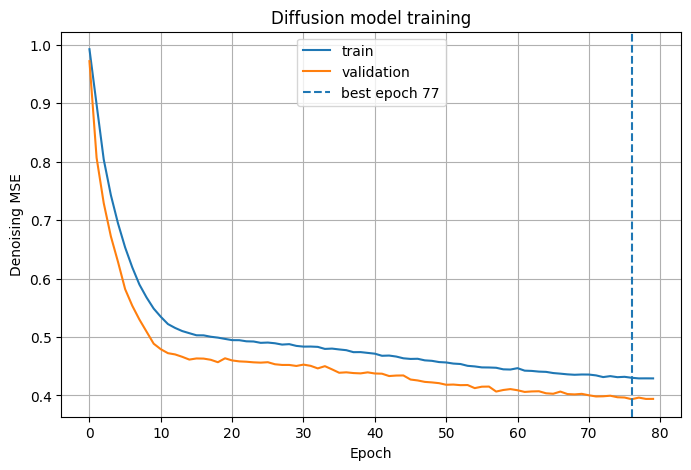

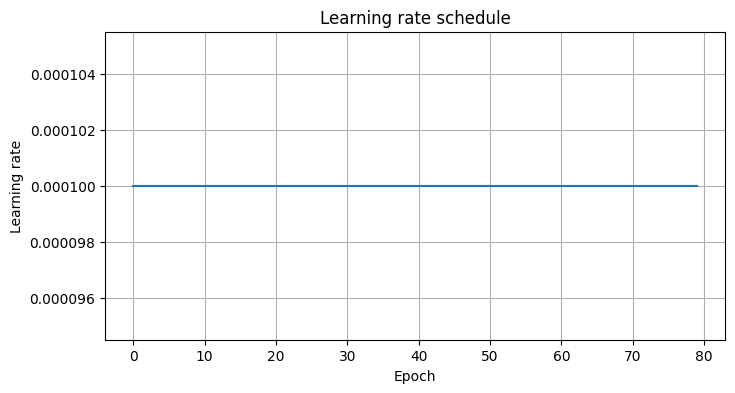

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(train_loss_history, label="train")
plt.plot(val_loss_history, label="validation")
plt.axvline(best_epoch - 1, linestyle="--", label=f"best epoch {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Denoising MSE")
plt.title("Diffusion model training")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(lr_history)
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.title("Learning rate schedule")
plt.grid(True)
plt.show()

## 15. Anomaly score: denoising error

In [15]:
# Score = errore medio nella predizione del rumore.
# Usiamo timestep fissi per ridurre la varianza dello score.
#
# score medio = media su timesteps selezionati
# score_low/mid/high = utile per capire quale livello di rumore separa meglio.

timesteps_eval = torch.tensor(
    [5, 10, 20, 40, 70, 100, 140, 180],
    dtype=torch.long,
    device=device,
)

low_timesteps = torch.tensor([5, 10, 20], dtype=torch.long, device=device)
mid_timesteps = torch.tensor([40, 70, 100], dtype=torch.long, device=device)
high_timesteps = torch.tensor([140, 180], dtype=torch.long, device=device)

print("timesteps_eval:", timesteps_eval.detach().cpu().numpy())


def compute_diffusion_scores(model, X, timesteps, batch_size=2048, n_noise_repeats=1):
    dataset = DiffusionDataset(X)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    model.eval()
    all_scores = []

    with torch.no_grad():
        for X_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            B = X_batch.shape[0]

            score_sum = torch.zeros(B, device=device)
            count = 0

            for t_scalar in timesteps:
                t = torch.full((B,), int(t_scalar.item()), device=device, dtype=torch.long)

                for _ in range(n_noise_repeats):
                    noise = torch.randn_like(X_batch)
                    xt, true_noise = q_sample(X_batch, t, noise=noise)
                    pred_noise = model(xt, t)

                    mse_per_sample = torch.mean((pred_noise - true_noise) ** 2, dim=1)

                    score_sum += mse_per_sample
                    count += 1

            score = score_sum / count
            all_scores.append(score.cpu().numpy())

    return np.concatenate(all_scores)


scores_train = compute_diffusion_scores(model, A_train_norm, timesteps_eval, batch_size=2048, n_noise_repeats=1)
scores_bg = compute_diffusion_scores(model, A_bg_norm, timesteps_eval, batch_size=2048, n_noise_repeats=1)
scores_sig = compute_diffusion_scores(model, A_sig_norm, timesteps_eval, batch_size=2048, n_noise_repeats=1)

scores_bg_low = compute_diffusion_scores(model, A_bg_norm, low_timesteps, batch_size=2048, n_noise_repeats=1)
scores_sig_low = compute_diffusion_scores(model, A_sig_norm, low_timesteps, batch_size=2048, n_noise_repeats=1)

scores_bg_mid = compute_diffusion_scores(model, A_bg_norm, mid_timesteps, batch_size=2048, n_noise_repeats=1)
scores_sig_mid = compute_diffusion_scores(model, A_sig_norm, mid_timesteps, batch_size=2048, n_noise_repeats=1)

scores_bg_high = compute_diffusion_scores(model, A_bg_norm, high_timesteps, batch_size=2048, n_noise_repeats=1)
scores_sig_high = compute_diffusion_scores(model, A_sig_norm, high_timesteps, batch_size=2048, n_noise_repeats=1)


def print_score_summary(name, scores):
    print("\n", name)
    print("mean:", scores.mean())
    print("std:", scores.std())
    print("median:", np.median(scores))
    print("quantiles:", np.percentile(scores, [0, 1, 5, 25, 50, 75, 95, 99, 99.9, 100]))


print_score_summary("train diffusion score", scores_train)
print_score_summary("background diffusion score", scores_bg)
print_score_summary("signal diffusion score", scores_sig)

timesteps_eval: [  5  10  20  40  70 100 140 180]

 train diffusion score
mean: 0.55038494
std: 0.05680615
median: 0.5461395
quantiles: [0.37845486 0.44952688 0.47610785 0.51587903 0.54613945 0.57924064
 0.63516495 0.6876755  0.98607379 4.60791111]

 background diffusion score
mean: 0.55068946
std: 0.053420514
median: 0.54669416
quantiles: [0.38114738 0.4493219  0.47563544 0.51596969 0.54669416 0.57973982
 0.63641968 0.6894256  0.97605245 1.83258402]

 signal diffusion score
mean: 0.62967134
std: 0.29414517
median: 0.6003831
quantiles: [0.41499943 0.48204    0.51253363 0.56109786 0.6003831  0.64705405
 0.75150012 0.89080362 5.11127187 6.90631294]


## 16. ROC/AUC e plot

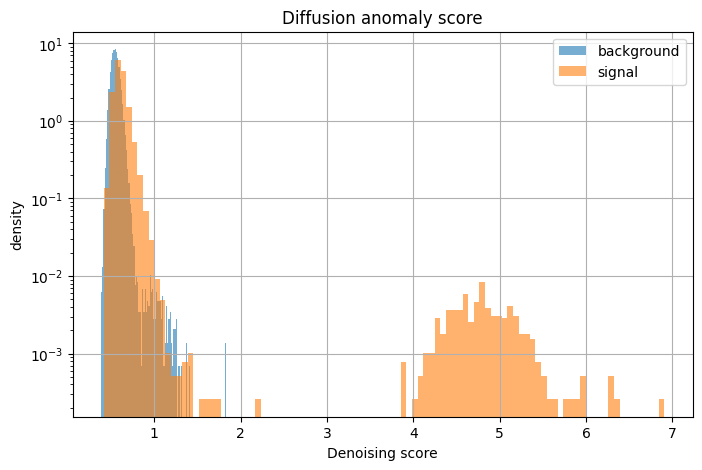

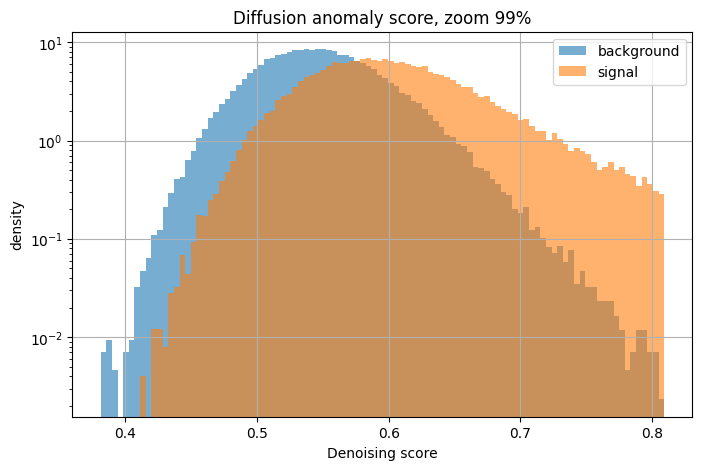


Diffusion mean denoising score ROC
AUC: 0.7602828448434853
AUC inverted: 0.2397171551565146
Best AUC: 0.7602828448434853


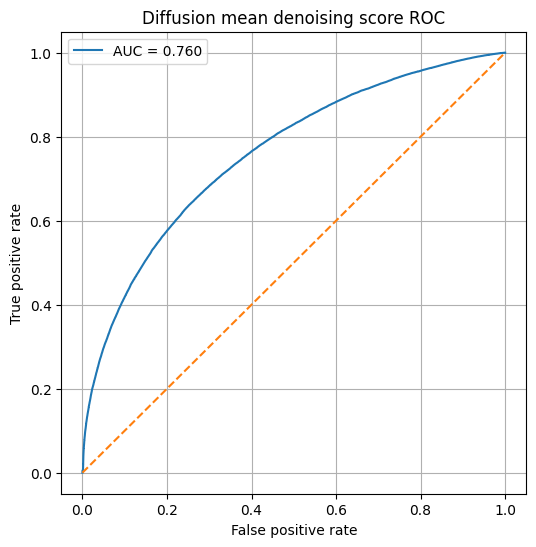


Diffusion low-timestep score ROC
AUC: 0.609073551883708
AUC inverted: 0.39092644811629196
Best AUC: 0.609073551883708


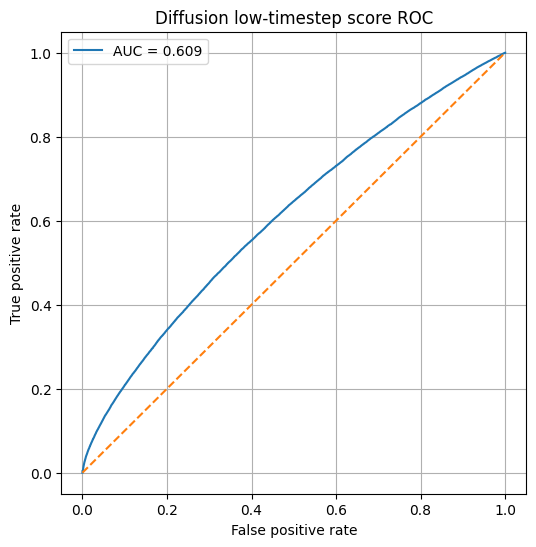


Diffusion mid-timestep score ROC
AUC: 0.7698979886994283
AUC inverted: 0.23010201130057173
Best AUC: 0.7698979886994283


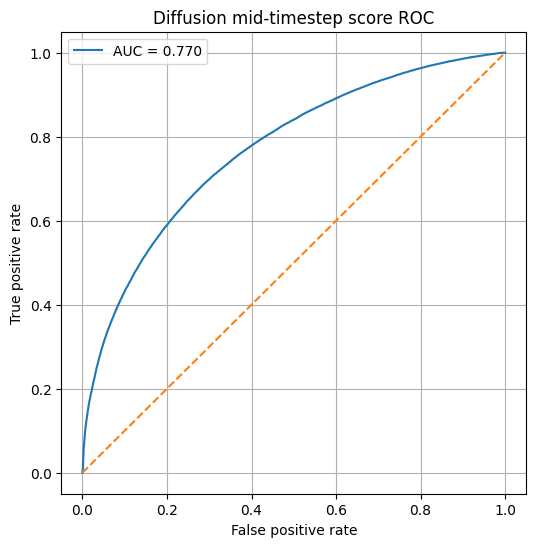


Diffusion high-timestep score ROC
AUC: 0.7554974625689519
AUC inverted: 0.24450253743104805
Best AUC: 0.7554974625689519


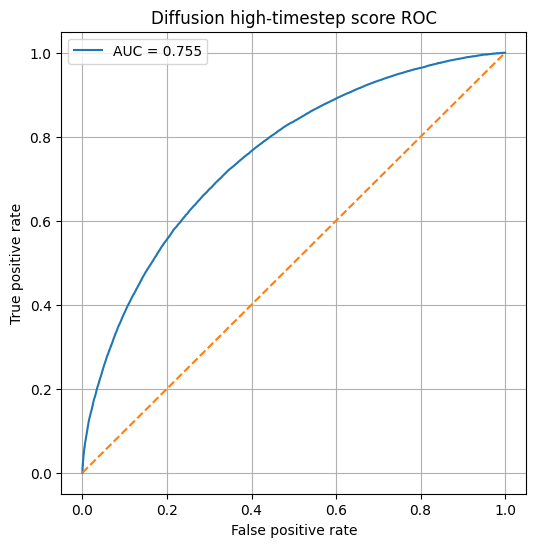

In [16]:
def evaluate_binary_scores(bg_scores, sig_scores, title):
    y_true = np.concatenate([
        np.zeros_like(bg_scores),
        np.ones_like(sig_scores),
    ])

    y_score = np.concatenate([
        bg_scores,
        sig_scores,
    ])

    auc = roc_auc_score(y_true, y_score)
    auc_inv = roc_auc_score(y_true, -y_score)
    best_auc = max(auc, auc_inv)

    print("\n" + title)
    print("AUC:", auc)
    print("AUC inverted:", auc_inv)
    print("Best AUC:", best_auc)

    if auc_inv > auc:
        plot_score = -y_score
        label = f"AUC inverted = {auc_inv:.3f}"
    else:
        plot_score = y_score
        label = f"AUC = {auc:.3f}"

    fpr, tpr, _ = roc_curve(y_true, plot_score)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=label)
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    return auc, auc_inv, best_auc


def plot_score_distribution(bg_scores, sig_scores, title, zoom_percentile=None):
    plt.figure(figsize=(8, 5))

    if zoom_percentile is not None:
        hi = np.percentile(np.concatenate([bg_scores, sig_scores]), zoom_percentile)
        plot_range = (min(bg_scores.min(), sig_scores.min()), hi)
    else:
        plot_range = None

    plt.hist(bg_scores, bins=100, range=plot_range, density=True, alpha=0.6, label="background")
    plt.hist(sig_scores, bins=100, range=plot_range, density=True, alpha=0.6, label="signal")
    plt.yscale("log")
    plt.xlabel("Denoising score")
    plt.ylabel("density")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_score_distribution(scores_bg, scores_sig, "Diffusion anomaly score")
plot_score_distribution(scores_bg, scores_sig, "Diffusion anomaly score, zoom 99%", zoom_percentile=99)

auc_diff, auc_diff_inv, best_auc_diff = evaluate_binary_scores(
    scores_bg,
    scores_sig,
    "Diffusion mean denoising score ROC",
)

auc_low, auc_low_inv, best_auc_low = evaluate_binary_scores(
    scores_bg_low,
    scores_sig_low,
    "Diffusion low-timestep score ROC",
)

auc_mid, auc_mid_inv, best_auc_mid = evaluate_binary_scores(
    scores_bg_mid,
    scores_sig_mid,
    "Diffusion mid-timestep score ROC",
)

auc_high, auc_high_inv, best_auc_high = evaluate_binary_scores(
    scores_bg_high,
    scores_sig_high,
    "Diffusion high-timestep score ROC",
)

## 17. Train vs test background

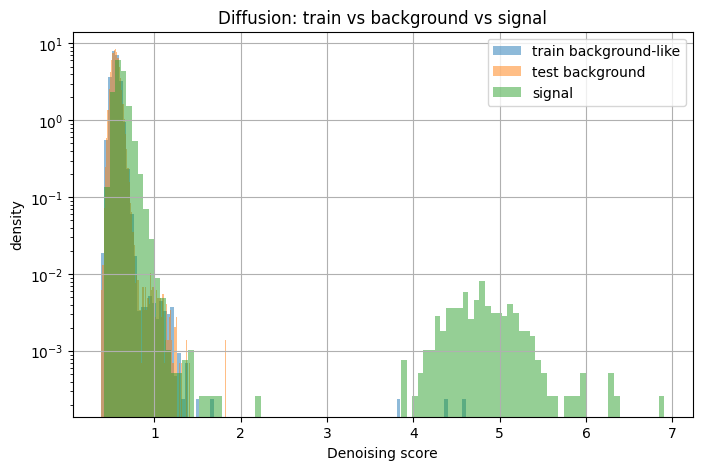

Train vs test background AUC: 0.5021154869
Train vs test background AUC inverted: 0.49788451310000004
Best train-vs-test-background AUC: 0.5021154869


In [17]:
def compare_train_bg_sig(train_scores, bg_scores, sig_scores, title):
    plt.figure(figsize=(8, 5))
    plt.hist(train_scores, bins=100, density=True, alpha=0.5, label="train background-like")
    plt.hist(bg_scores, bins=100, density=True, alpha=0.5, label="test background")
    plt.hist(sig_scores, bins=100, density=True, alpha=0.5, label="signal")
    plt.yscale("log")
    plt.xlabel("Denoising score")
    plt.ylabel("density")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    y = np.concatenate([
        np.zeros_like(train_scores),
        np.ones_like(bg_scores),
    ])

    s = np.concatenate([
        train_scores,
        bg_scores,
    ])

    auc_tb = roc_auc_score(y, s)
    auc_tb_inv = roc_auc_score(y, -s)
    best_auc_tb = max(auc_tb, auc_tb_inv)

    print("Train vs test background AUC:", auc_tb)
    print("Train vs test background AUC inverted:", auc_tb_inv)
    print("Best train-vs-test-background AUC:", best_auc_tb)

    return auc_tb, auc_tb_inv, best_auc_tb


auc_train_bg, auc_train_bg_inv, best_auc_train_bg = compare_train_bg_sig(
    scores_train,
    scores_bg,
    scores_sig,
    "Diffusion: train vs background vs signal",
)

## 18. Track-only diagnostic

In [18]:
# Diagnostica supervisionata track-only, come nei notebook precedenti.

A_train_tracks_only = build_aggregate_matrix(
    X_jets_train,
    X_tracks_train,
    mask_train,
    use_jets=False,
    use_tracks=True,
)

A_bg_tracks_only = build_aggregate_matrix(
    X_jets_bg,
    X_tracks_bg,
    mask_bg,
    use_jets=False,
    use_tracks=True,
)

A_sig_tracks_only = build_aggregate_matrix(
    X_jets_sig,
    X_tracks_sig,
    mask_sig,
    use_jets=False,
    use_tracks=True,
)

center_to = np.median(A_train_tracks_only, axis=0, keepdims=True)
q25_to = np.percentile(A_train_tracks_only, 25, axis=0, keepdims=True)
q75_to = np.percentile(A_train_tracks_only, 75, axis=0, keepdims=True)
scale_to = np.maximum(q75_to - q25_to, 1e-6)

A_bg_tracks_only_norm = np.clip(((A_bg_tracks_only - center_to) / scale_to), -CLIP_VALUE, CLIP_VALUE).astype(np.float32)
A_sig_tracks_only_norm = np.clip(((A_sig_tracks_only - center_to) / scale_to), -CLIP_VALUE, CLIP_VALUE).astype(np.float32)

X_clf_to = np.concatenate([A_bg_tracks_only_norm, A_sig_tracks_only_norm], axis=0)
y_clf_to = np.concatenate([
    np.zeros(A_bg_tracks_only_norm.shape[0], dtype=np.int64),
    np.ones(A_sig_tracks_only_norm.shape[0], dtype=np.int64),
])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf_to,
    y_clf_to,
    test_size=0.3,
    random_state=42,
    stratify=y_clf_to,
)

clf_to = LogisticRegression(max_iter=3000)
clf_to.fit(X_tr, y_tr)
proba_to = clf_to.predict_proba(X_te)[:, 1]
auc_track_only_logreg = roc_auc_score(y_te, proba_to)

print("Track-only supervised logistic regression AUC:", auc_track_only_logreg)

Track-only supervised logistic regression AUC: 0.9895588349261348


## 19. Sampling opzionale dal diffusion model

sampled shape: (5000, 75)
sampled finite: True
sampled mean/std: 0.01895683 0.90913296
sampled quantiles: [-10.48269939  -2.53786793  -1.30875401  -0.43823393   0.01222673
   0.48426846   1.39694919   2.43719735  11.68132114]


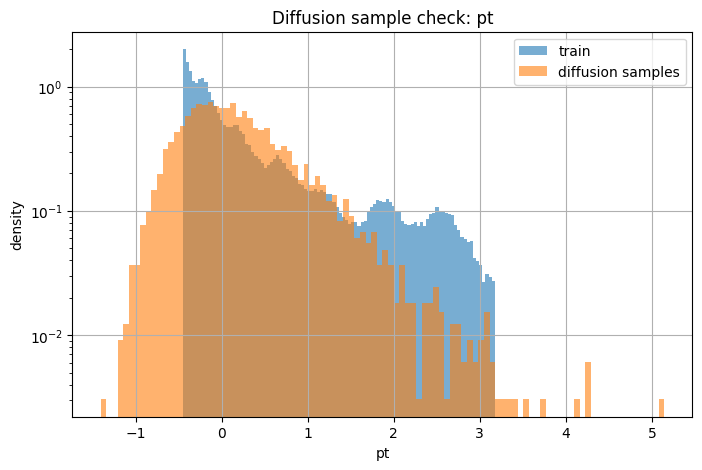

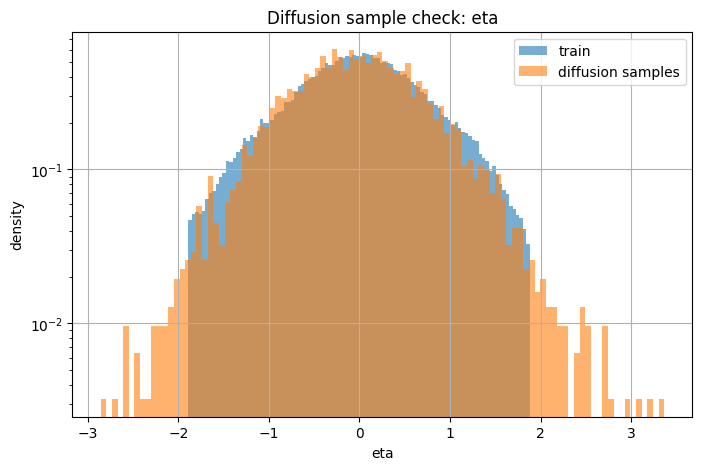

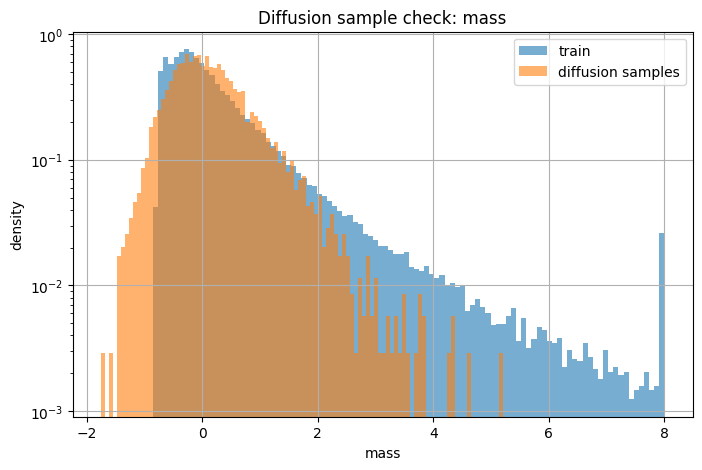

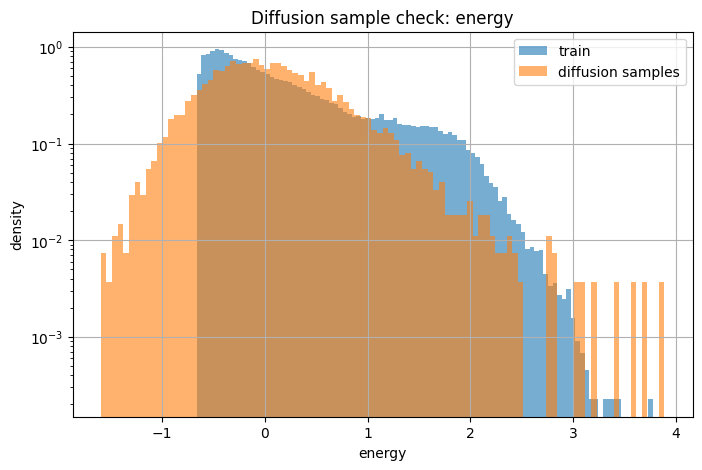

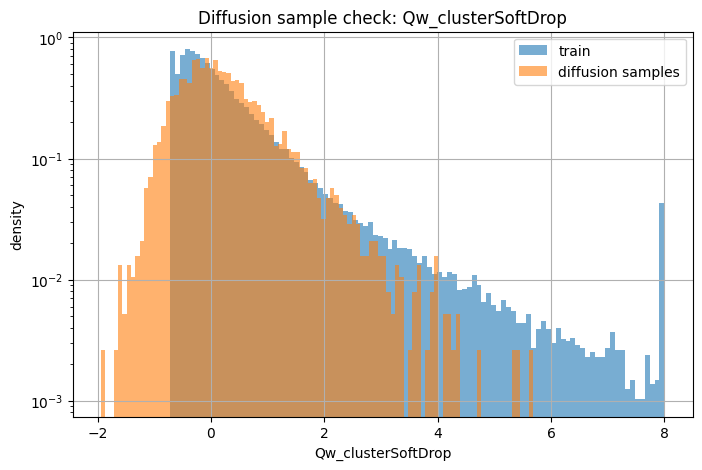

In [19]:
# Sampling DDPM inverso semplificato.
# Per tabular data non è il punto principale del notebook,
# ma serve come sanity check generativo.

@torch.no_grad()
def sample_diffusion(model, n_samples, input_dim):
    model.eval()

    x = torch.randn(n_samples, input_dim, device=device)

    for t_int in reversed(range(T)):
        t = torch.full((n_samples,), t_int, device=device, dtype=torch.long)

        beta_t = betas[t].unsqueeze(1)
        alpha_t = alphas[t].unsqueeze(1)
        alpha_bar_t = alpha_bars[t].unsqueeze(1)

        eps_pred = model(x, t)

        # DDPM mean
        mean = (1.0 / torch.sqrt(alpha_t)) * (
            x - (beta_t / torch.sqrt(1.0 - alpha_bar_t)) * eps_pred
        )

        if t_int > 0:
            noise = torch.randn_like(x)
            x = mean + torch.sqrt(beta_t) * noise
        else:
            x = mean

    return x.cpu().numpy()


n_samples = 5000
x_sampled = sample_diffusion(model, n_samples=n_samples, input_dim=input_dim)

print("sampled shape:", x_sampled.shape)
print("sampled finite:", np.isfinite(x_sampled).all())
print("sampled mean/std:", x_sampled.mean(), x_sampled.std())
print("sampled quantiles:", np.percentile(x_sampled.ravel(), [0, 1, 5, 25, 50, 75, 95, 99, 100]))

for i in range(min(5, input_dim)):
    plt.figure(figsize=(8, 5))
    plt.hist(A_train_norm[:, i], bins=100, density=True, alpha=0.6, label="train")
    plt.hist(x_sampled[:, i], bins=100, density=True, alpha=0.6, label="diffusion samples")
    plt.yscale("log")
    plt.xlabel(aggregate_feature_names[i])
    plt.ylabel("density")
    plt.title(f"Diffusion sample check: {aggregate_feature_names[i]}")
    plt.legend()
    plt.grid(True)
    plt.show()

## 20. Salvataggio

In [20]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "input_dim": input_dim,
        "T": T,
        "beta_start": beta_start,
        "beta_end": beta_end,
        "time_emb_dim": time_emb_dim,
        "hidden_dim": hidden_dim,
        "dropout": dropout,
        "learning_rate": learning_rate,
        "aggregate_feature_names": aggregate_feature_names,
        "center": center,
        "scale": scale,
        "clip_value": CLIP_VALUE,
        "robust_scale": ROBUST_SCALE,
        "train_loss_history": train_loss_history,
        "val_loss_history": val_loss_history,
        "lr_history": lr_history,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "auc_diff": auc_diff,
        "auc_diff_inv": auc_diff_inv,
        "best_auc_diff": best_auc_diff,
        "auc_low": auc_low,
        "best_auc_low": best_auc_low,
        "auc_mid": auc_mid,
        "best_auc_mid": best_auc_mid,
        "auc_high": auc_high,
        "best_auc_high": best_auc_high,
        "auc_train_bg": auc_train_bg,
        "best_auc_train_bg": best_auc_train_bg,
        "auc_logreg": auc_logreg,
        "auc_track_only_logreg": auc_track_only_logreg,
    },
    OUTPUT_DIR / "tabular_diffusion_model.pt",
)

np.savez_compressed(
    OUTPUT_DIR / "tabular_diffusion_scores.npz",
    scores_train=scores_train,
    scores_bg=scores_bg,
    scores_sig=scores_sig,
    scores_bg_low=scores_bg_low,
    scores_sig_low=scores_sig_low,
    scores_bg_mid=scores_bg_mid,
    scores_sig_mid=scores_sig_mid,
    scores_bg_high=scores_bg_high,
    scores_sig_high=scores_sig_high,
    aggregate_feature_names=np.array(aggregate_feature_names, dtype=object),
    auc_diff=np.array(auc_diff, dtype=np.float32),
    auc_diff_inv=np.array(auc_diff_inv, dtype=np.float32),
    best_auc_diff=np.array(best_auc_diff, dtype=np.float32),
    auc_low=np.array(auc_low, dtype=np.float32),
    best_auc_low=np.array(best_auc_low, dtype=np.float32),
    auc_mid=np.array(auc_mid, dtype=np.float32),
    best_auc_mid=np.array(best_auc_mid, dtype=np.float32),
    auc_high=np.array(auc_high, dtype=np.float32),
    best_auc_high=np.array(best_auc_high, dtype=np.float32),
    auc_train_bg=np.array(auc_train_bg, dtype=np.float32),
    auc_train_bg_inv=np.array(auc_train_bg_inv, dtype=np.float32),
    best_auc_train_bg=np.array(best_auc_train_bg, dtype=np.float32),
    auc_logreg=np.array(auc_logreg, dtype=np.float32),
    auc_track_only_logreg=np.array(auc_track_only_logreg, dtype=np.float32),
)

config = {
    "dataset_name": DATASET_NAME,
    "processed_files": {k: str(v) for k, v in processed_files.items()},
    "EVAL_ONLY_TRUE_DISPLACED_SIGNAL": EVAL_ONLY_TRUE_DISPLACED_SIGNAL,
    "USE_JET_FEATURES": USE_JET_FEATURES,
    "USE_TRACK_AGGREGATES": USE_TRACK_AGGREGATES,
    "jet_features": jet_feature_names,
    "track_features": track_feature_names,
    "input_dim": int(input_dim),
    "robust_scale": bool(ROBUST_SCALE),
    "clip_value": float(CLIP_VALUE),
    "T": int(T),
    "beta_start": float(beta_start),
    "beta_end": float(beta_end),
    "time_emb_dim": int(time_emb_dim),
    "hidden_dim": int(hidden_dim),
    "dropout": float(dropout),
    "learning_rate": float(learning_rate),
    "batch_size": int(batch_size),
    "n_epochs_requested": int(n_epochs),
    "best_epoch": int(best_epoch),
    "best_val_loss": float(best_val_loss),
    "best_auc_diff": float(best_auc_diff),
    "best_auc_low": float(best_auc_low),
    "best_auc_mid": float(best_auc_mid),
    "best_auc_high": float(best_auc_high),
    "best_auc_train_bg": float(best_auc_train_bg),
    "auc_logreg": float(auc_logreg),
    "auc_track_only_logreg": float(auc_track_only_logreg),
}

with open(OUTPUT_DIR / "tabular_diffusion_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved:")
print(OUTPUT_DIR / "tabular_diffusion_model.pt")
print(OUTPUT_DIR / "tabular_diffusion_scores.npz")
print(OUTPUT_DIR / "tabular_diffusion_config.json")

Saved:
outputs_diffusion\tabular_diffusion_model.pt
outputs_diffusion\tabular_diffusion_scores.npz
outputs_diffusion\tabular_diffusion_config.json


## Come interpretare i risultati

- **Training loss**: è la MSE nella predizione del rumore. Deve scendere/stabilizzarsi.
- **Diffusion score**: è la MSE media di denoising. Più alto significa più anomalo.
- **AUC background vs signal**: misura la qualità dell'anomaly score.
- **Train vs test background AUC**: deve essere vicino a 0.5. Se è alto, c'è domain shift.
- **Low/mid/high timestep score**: dice a quale livello di rumore il modello distingue meglio signal e background.
- **Sampling**: è solo un sanity check generativo, non il risultato principale.